# Single-Example BrushNet Comparison

This notebook runs the same four implementations as the resumable BrushBench evaluation. Every method receives the same source, mask, prompt, and independent initial latent tensor.

In [ ]:
from dataclasses import replace
from pathlib import Path
import os
import sys

ROOT = Path.cwd()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

# Set these paths before importing the inpainting modules.
BRUSHNET_ROOT = Path(os.environ.get(
    'BRUSHNET_ROOT',
    ROOT.parent / 'Image_inpaiting pullback' / 'BrushNet',
))
# 
os.environ.setdefault('BRUSHNET_ROOT', str(BRUSHNET_ROOT))
os.environ.setdefault('BRUSHNET_BASE_MODEL', str(BRUSHNET_ROOT / 'checkpoints' / 'JuggernautXL-v9'))
os.environ.setdefault('BRUSHNET_MODEL', str(BRUSHNET_ROOT / 'checkpoints' / 'brushnet_sdxl'))
os.environ.setdefault('BRUSHBENCH_ROOT', str(BRUSHNET_ROOT / 'data' / 'BrushBench'))

os.environ['BRUSHNET_MODEL_FAMILY'] = 'sdxl'

# os.environ['BRUSHNET_BASE_MODEL'] = (
#     'stabilityai/stable-diffusion-xl-base-1.0'
# )

# os.environ['BRUSHNET_MODEL'] = str(
#     BRUSHNET_ROOT / 'checkpoints' / 'brushnet_sdxl'
# )
EXAMPLE_KEY = '000000031'
SELECTED_METHODS = ['clean_ddim', 'cads', 'adaptive_pullback', 'tpso']
RESPONSE_REGION = 'edit_mask'  # use 'edit_mask' for the regional operator

In [2]:
import matplotlib.pyplot as plt
import pandas as pd

from configs.inpainting import EXPERIMENT
from evaluation.inpainting_metrics import InpaintingMetrics
from inpainting import data, experiment, model

config = replace(EXPERIMENT, pullback_response_region=RESPONSE_REGION)
pipe = model.load_pipeline()
example = data.load_example(EXAMPLE_KEY)
sample = experiment.prepare_example(pipe, example, config)
metrics = InpaintingMetrics(device=str(pipe._execution_device))
print(example.key, example.prompt)
print('initial latents:', tuple(sample.initial_latents.shape))

/home/dehay/miniconda3/envs/ppt/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/dehay/Sylvain/Image_inpaiting pullback/BrushNet/src/diffusers/models/lora.py:387: FutureWarning: `LoRACompatibleLinear` is deprecated and will be removed in version 1.0.0. Use of `LoRACompatibleLinear` is deprecated. Please switch to PEFT backend by installing PEFT: `pip install peft`.
  deprecate("LoRACompatibleLinear", "1.0.0", deprecation_message)
/home/dehay/Sylvain/Image_inpaiting pullback/BrushNet/src/diffusers/models/lora.py:300: FutureWarning: `LoRACompatibleConv` is deprecated and will be removed in version 1.0.0. Use of `LoRACompatibleConv` is deprecated. Please switch to PEFT backend by installing PEFT: `pip install peft`.
  deprecate("LoRACompatibleConv", "1.0.0", deprecation_message)
Loading pipeline compo

000000031 a young girl holding a husky dog on a black background
initial latents: (4, 4, 128, 128)


## Prepare Method-Specific State

The pullback method computes its basis once before the shared sampler restarts. TPSO optimizes its token offsets before sampling.

In [3]:
basis = None
eigenvalues = None
optimized_tpso = None

if 'adaptive_pullback' in SELECTED_METHODS:
    basis, eigenvalues = experiment.compute_initial_basis(
        pipe, sample, config, cache_dir=ROOT / 'outputs' / 'notebook_basis_cache'
    )
    print('pullback eigenvalues:', [round(float(x), 4) for x in eigenvalues[:8]])

if 'tpso' in SELECTED_METHODS:
    optimized_tpso = experiment.optimize_tpso(pipe, sample, config)
    print('TPSO steps:', optimized_tpso.steps_run)

pullback eigenvalues: [0.1955, 0.1514, 0.1229, 0.1034, 0.0841, 0.0765, 0.067, 0.054]
TPSO 001/200: joint=1.7600 clean_cos=1.0000 pair_cos=1.0000
TPSO 010/200: joint=0.6174 clean_cos=0.7948 pair_cos=0.6171
TPSO 020/200: joint=0.5817 clean_cos=0.7867 pair_cos=0.5601
TPSO 030/200: joint=0.5653 clean_cos=0.7912 pair_cos=0.5488
TPSO 040/200: joint=0.5508 clean_cos=0.7944 pair_cos=0.5413
TPSO 050/200: joint=0.5367 clean_cos=0.7893 pair_cos=0.5226
TPSO 060/200: joint=0.5318 clean_cos=0.7873 pair_cos=0.5130
TPSO 070/200: joint=0.5225 clean_cos=0.7933 pair_cos=0.5209
TPSO 080/200: joint=0.5146 clean_cos=0.7883 pair_cos=0.5074
TPSO 090/200: joint=0.5143 clean_cos=0.7901 pair_cos=0.5090
TPSO 100/200: joint=0.5124 clean_cos=0.7907 pair_cos=0.5085
TPSO 110/200: joint=0.5120 clean_cos=0.7886 pair_cos=0.5032
TPSO 120/200: joint=0.5109 clean_cos=0.7874 pair_cos=0.5006
TPSO 130/200: joint=0.5118 clean_cos=0.7904 pair_cos=0.5058
TPSO 140/200: joint=0.5118 clean_cos=0.7891 pair_cos=0.5026
TPSO 150/200: j

In [4]:
images_by_method = {}
raw_by_method = {}
tpso_alpha_trace = None

for method_name in SELECTED_METHODS:
    if method_name == 'clean_ddim':
        raw, blended = experiment.run_clean_ddim(pipe, sample, config)
    elif method_name == 'cads':
        raw, blended = experiment.run_cads(pipe, sample, config)
    elif method_name == 'adaptive_pullback':
        raw, blended = experiment.run_adaptive_pullback(
            pipe, sample, basis, config
        )
    elif method_name == 'tpso':
        raw, blended, tpso_alpha_trace = experiment.run_tpso(
            pipe, sample, optimized_tpso, config
        )
    else:
        raise ValueError(f'unknown method: {method_name}')
    raw_by_method[method_name] = raw
    images_by_method[method_name] = blended

adaptive pullback refresh timesteps: [839, 659]


adaptive pullback:  16%|█▋        | 8/49 [00:15<01:21,  1.99s/it]

recomputing rank-8 pullback basis at t=839 from particle 0
intermediate pullback eigenvalues: ['0.12', '0.0607', '0.0407', '0.0166', '0.0145', '0.00696', '0.00648', '0.00241']


adaptive pullback:  35%|███▍      | 17/49 [00:45<01:10,  2.20s/it]

recomputing rank-8 pullback basis at t=659 from particle 0
intermediate pullback eigenvalues: ['0.233', '0.109', '0.0575', '0.0456', '0.0411', '0.027', '0.0267', '0.0189']


/home/dehay/miniconda3/envs/ppt/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/dehay/miniconda3/envs/ppt/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
/home/dehay/miniconda3/envs/ppt/lib/python3.10/site-packages/huggingface_hub/file_download.py:1132: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Could not find image processor c

,method,lpips_mean,lpips_min,dino_sim_mean,dino_sim_max,vendi,clip,mss
0,clean_ddim,0.114680,0.105065,0.999441,0.999585,1.030201,40.933606,0.994702
1,cads,0.114913,0.103414,0.999528,0.999698,1.030241,40.983306,0.994660
2,adaptive_pullback,0.216273,0.173670,0.998200,0.999224,1.067010,40.945713,0.987055
3,tpso,0.128621,0.096180,0.999366,0.999511,1.037954,41.043826,0.993184


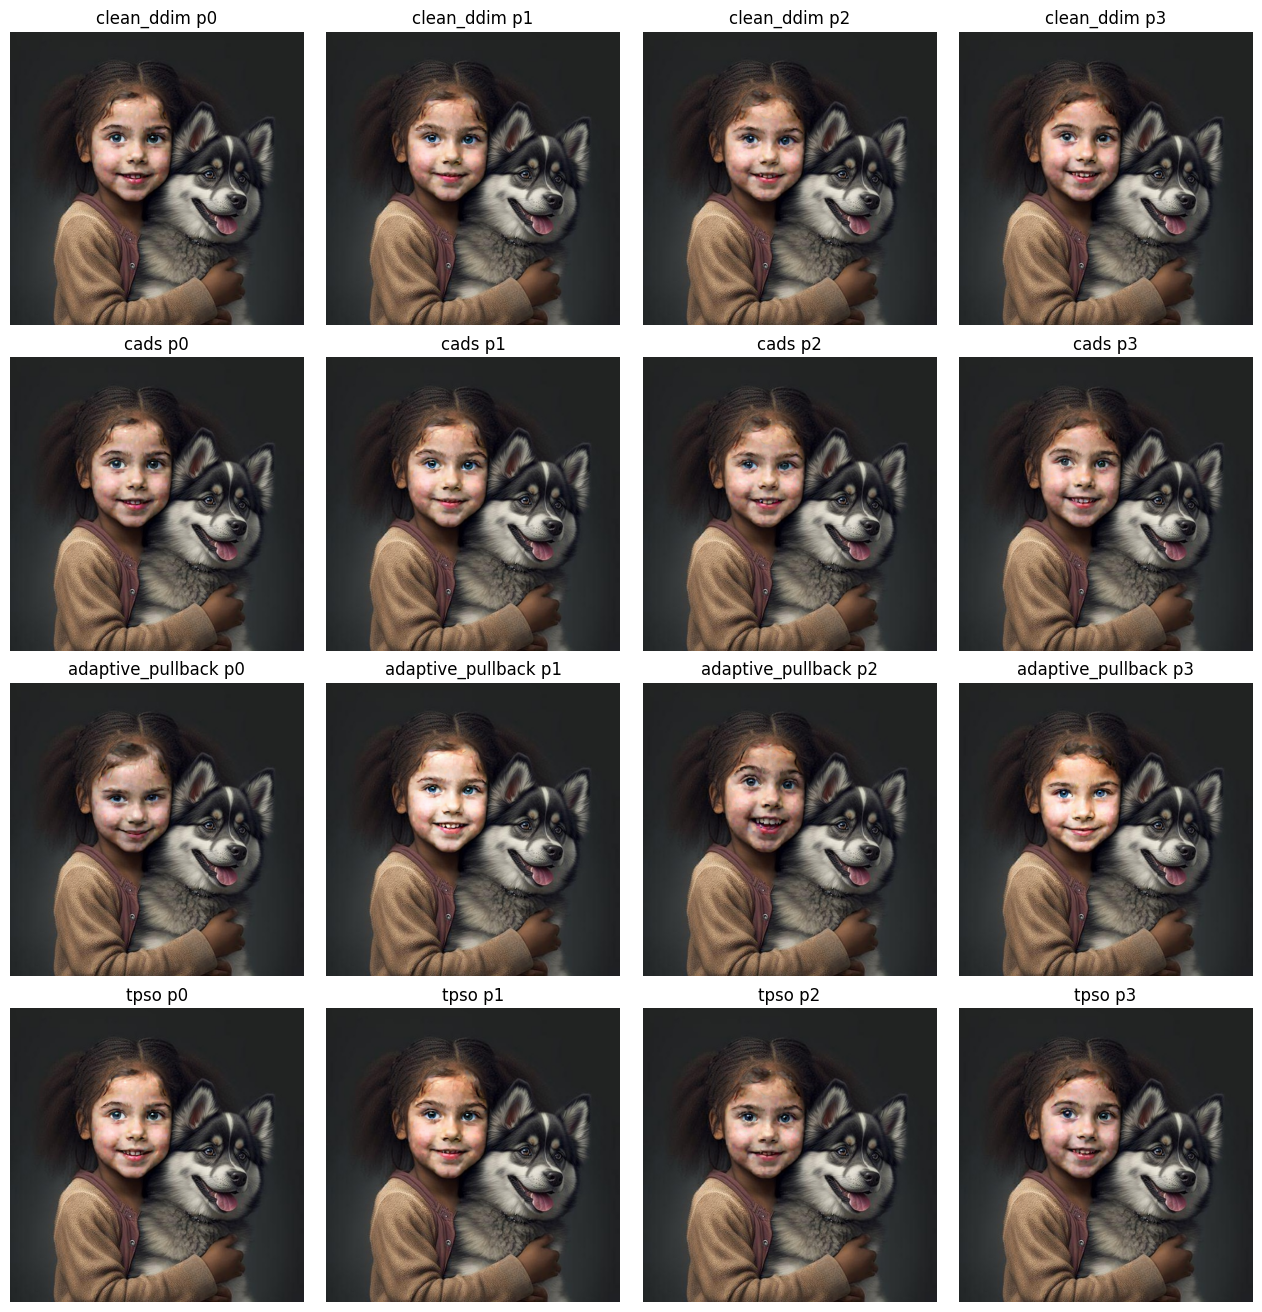

In [5]:
rows = []
for method_name, images in images_by_method.items():
    values = metrics.full_metrics(images, example.prompt, sample.edit_mask_image)
    rows.append({'method': method_name, **values})
display(pd.DataFrame(rows)[
    ['method', 'lpips_mean', 'lpips_min', 'dino_sim_mean',
     'dino_sim_max', 'vendi', 'clip', 'mss']
])

fig, axes = plt.subplots(
    len(images_by_method), config.num_particles,
    figsize=(3.2 * config.num_particles, 3.3 * len(images_by_method)),
    squeeze=False,
)
for row, (method_name, images) in enumerate(images_by_method.items()):
    for particle, image in enumerate(images):
        axes[row, particle].imshow(image)
        axes[row, particle].set_title(f'{method_name} p{particle}')
        axes[row, particle].axis('off')
plt.tight_layout()
plt.show()